In [43]:
import torch
import torch.nn as nn
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder
from torch.nn.utils.rnn import pad_sequence
import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
import string

In [44]:
data = pd.read_csv('/content/bbc-text.csv')
data.head()

,category,text
0,tech,tv future in the hands of viewers with home th...
1,business,worldcom boss left books alone former worldc...
2,sport,tigers wary of farrell gamble leicester say ...
3,sport,yeading face newcastle in fa cup premiership s...
4,entertainment,ocean s twelve raids box office ocean s twelve...


In [45]:
data['category'].unique()

array(['tech', 'business', 'sport', 'entertainment', 'politics'],
      dtype=object)

In [46]:
encoder = LabelEncoder()
data['label'] = encoder.fit_transform(data['category'])
data.head()

,category,text,label
0,tech,tv future in the hands of viewers with home th...,4
1,business,worldcom boss left books alone former worldc...,0
2,sport,tigers wary of farrell gamble leicester say ...,3
3,sport,yeading face newcastle in fa cup premiership s...,3
4,entertainment,ocean s twelve raids box office ocean s twelve...,1


In [47]:
train_data = data.sample(frac=0.7, random_state=42)
test_data = data.drop(train_data.index)
val_data = test_data.sample(frac=0.5, random_state=42)
test_data = test_data.drop(val_data.index)

train_data.shape, test_data.shape, val_data.shape

((1558, 3), (333, 3), (334, 3))

In [48]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
device

'cuda'

In [49]:
class VanillaRNN(nn.Module):
  def __init__(self, vocab_size, embedding_dim, hidden_size, output_size):
    super(VanillaRNN, self).__init__()
    self.hidden_size = hidden_size
    self.embedding = nn.Embedding(vocab_size, embedding_dim)
    self.rnn = nn.RNN(embedding_dim, hidden_size, batch_first=True)
    self.fc = nn.Linear(hidden_size, output_size)


  def forward(self, text):
    embedded = self.embedding(text)
    output, hidden = self.rnn(embedded)
    last_hidden = hidden[-1]
    output = self.fc(last_hidden)
    return output




In [50]:
nltk.download('punkt_tab')
nltk.download('stopwords')

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [51]:
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

english_stops = set(stopwords.words('english'))

def tokenize(text):
    tokens = word_tokenize(text.lower())
    clean_tokens = [w for w in tokens if w.isalpha() and w not in english_stops]
    return clean_tokens


In [52]:
words = []
for text in data['text']:
  words.extend(tokenize(text))

In [53]:
from collections import Counter

word_count = Counter(words)
common_words = [word for word, count in word_count.most_common(10000)]
word_to_id = {word: i + 2 for i , word in enumerate(common_words)}
vocab_size = len(word_to_id) + 2
vocab_size

10002

In [54]:
print("ID for 'tech':", word_to_id.get('tech'))

ID for 'tech': 3867


In [55]:
def encode(text):
  tokens = tokenize(text)
  encoded = [word_to_id.get(w, 1) for w in tokens]
  return torch.tensor(encoded, dtype=torch.long)

In [56]:
encode(data.iloc[0, 1])

tensor([  83,  140, 1121, 1103,   45, 1016,  666, 4852, 3956,  116,  159, 3818,
        1297, 1221, 1529,   38,    6,  851,   83, 6093,  285,   90,   19,   17,
         111, 2869, 1234, 2308,  517,  375, 1166,   60, 2730, 2870, 1611,    7,
         801,  678,   10,  855,    1,    8,  593, 1446,  947,  366, 1827, 1103,
         693,   45,  442, 1365, 1931, 1513,  109,  290,   98, 2531,  813, 4853,
         988,  541,   10,  801, 2359,  116,  307,  159, 3818, 8276, 5409, 3127,
          27,    8, 5410,   18,  115,  401,    6,  118, 1312,   66, 4272,  446,
        5094,   83,  947,   69, 6094,   71, 1932,   53, 8277,   83,    5,   83,
        1828,  124,  132,  370,    8, 2797,   36,  121, 1104, 4099,    6,  446,
        5094, 2871,    5, 2477,    1,  360, 1059, 8278, 1257,  546,  676,    8,
         442, 1365, 1931,  109, 1755,  364,  802, 1905, 1479,   40, 1774, 2360,
        4643, 5095, 2309,  211,    8, 2415,   71,  738,    5,  989, 1025,  121,
         713,  565, 8279,  110,   27, 16

In [57]:
MAX_LENGTH = 100
encoded_list_train = [encode(text) for text in train_data['text']]
X_tensor_train = pad_sequence(encoded_list_train, batch_first=True, padding_value=0)
X_tensor_train = X_tensor_train[:, :MAX_LENGTH]
y_tensor_train = torch.tensor(train_data['label'].values, dtype=torch.long)

encoded_list_val = [encode(text) for text in val_data['text']]
X_tensor_val = pad_sequence(encoded_list_val, batch_first=True, padding_value=0)
X_tensor_val = X_tensor_val[:, :MAX_LENGTH]
y_tensor_val = torch.tensor(val_data['label'].values, dtype=torch.long)

encoded_list_test = [encode(text) for text in test_data['text']]
X_tensor_test = pad_sequence(encoded_list_test, batch_first=True, padding_value=0)
X_tensor_test = X_tensor_test[:, :MAX_LENGTH]
y_tensor_test = torch.tensor(test_data['label'].values, dtype=torch.long)

In [58]:
from torch.utils.data import TensorDataset, DataLoader

BATCH_SIZE = 32

train_dataset = TensorDataset(X_tensor_train, y_tensor_train)
val_dataset = TensorDataset(X_tensor_val, y_tensor_val)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)


In [59]:
# --- Setup Hyperparameters & Model ---
EMBEDDING_DIM = 64
HIDDEN_SIZE = 128
OUTPUT_SIZE = 5 # Our 5 BBC categories
LEARNING_RATE = 0.001
EPOCHS = 20

model = VanillaRNN(vocab_size, EMBEDDING_DIM, HIDDEN_SIZE, OUTPUT_SIZE).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)

# Lists to track metrics for plotting later
train_loss_total = []
train_acc_total = []
val_loss_total = []
val_acc_total = []

for epoch in range(EPOCHS):

    # --- TRAINING PHASE ---
    model.train()
    train_loss = 0
    train_correct = 0
    train_total = 0

    for data, label in train_loader:
        # Move data to GPU
        data = data.to(device)
        label = label.to(device)

        # Forward pass
        prediction = model(data)
        loss = criterion(prediction, label)

        # Backward pass
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()


        train_loss += loss.item()
        predicated_class = torch.argmax(prediction, dim=1)


        train_correct += (predicated_class == label).sum().item()
        train_total += label.size(0)

    avg_train_loss = train_loss / len(train_loader)
    train_acc = (train_correct / train_total) * 100

    # --- VALIDATION PHASE ---
    with torch.no_grad():
        model.eval()
        val_loss = 0
        val_correct = 0
        val_total = 0

        for data, label in val_loader:
            data = data.to(device)
            label = label.to(device)

            prediction = model(data)
            loss = criterion(prediction, label)

            val_loss += loss.item()
            predicated_class = torch.argmax(prediction, dim=1)
            val_correct += (predicated_class == label).sum().item()
            val_total += label.size(0)

        avg_val_loss = val_loss / len(val_loader)
        val_acc = (val_correct / val_total) * 100


    train_loss_total.append(avg_train_loss)
    train_acc_total.append(train_acc)
    val_loss_total.append(avg_val_loss)
    val_acc_total.append(val_acc)

    # Print the results for this epoch
    print(f"Epoch [{epoch+1}/{EPOCHS}] "
          f"Train Loss: {avg_train_loss:.4f}, Train Acc: {train_acc:.2f}% | "
          f"Val Loss: {avg_val_loss:.4f}, Val Acc: {val_acc:.2f}%")

Epoch [1/20] Train Loss: 1.5892, Train Acc: 24.26% | Val Loss: 1.5715, Val Acc: 26.65%
Epoch [2/20] Train Loss: 1.4413, Train Acc: 39.60% | Val Loss: 1.5447, Val Acc: 30.24%
Epoch [3/20] Train Loss: 1.2889, Train Acc: 50.19% | Val Loss: 1.5441, Val Acc: 33.23%
Epoch [4/20] Train Loss: 1.1125, Train Acc: 58.66% | Val Loss: 1.5508, Val Acc: 35.33%
Epoch [5/20] Train Loss: 0.9271, Train Acc: 66.62% | Val Loss: 1.5209, Val Acc: 41.92%
Epoch [6/20] Train Loss: 0.7137, Train Acc: 76.83% | Val Loss: 1.6538, Val Acc: 39.22%
Epoch [7/20] Train Loss: 0.5523, Train Acc: 82.93% | Val Loss: 1.5114, Val Acc: 47.90%
Epoch [8/20] Train Loss: 0.4866, Train Acc: 85.30% | Val Loss: 1.6558, Val Acc: 45.81%
Epoch [9/20] Train Loss: 0.2994, Train Acc: 93.71% | Val Loss: 1.8383, Val Acc: 43.71%
Epoch [10/20] Train Loss: 0.2159, Train Acc: 95.96% | Val Loss: 1.8596, Val Acc: 46.41%
Epoch [11/20] Train Loss: 0.1410, Train Acc: 97.82% | Val Loss: 1.9636, Val Acc: 45.51%
Epoch [12/20] Train Loss: 0.1907, Train A

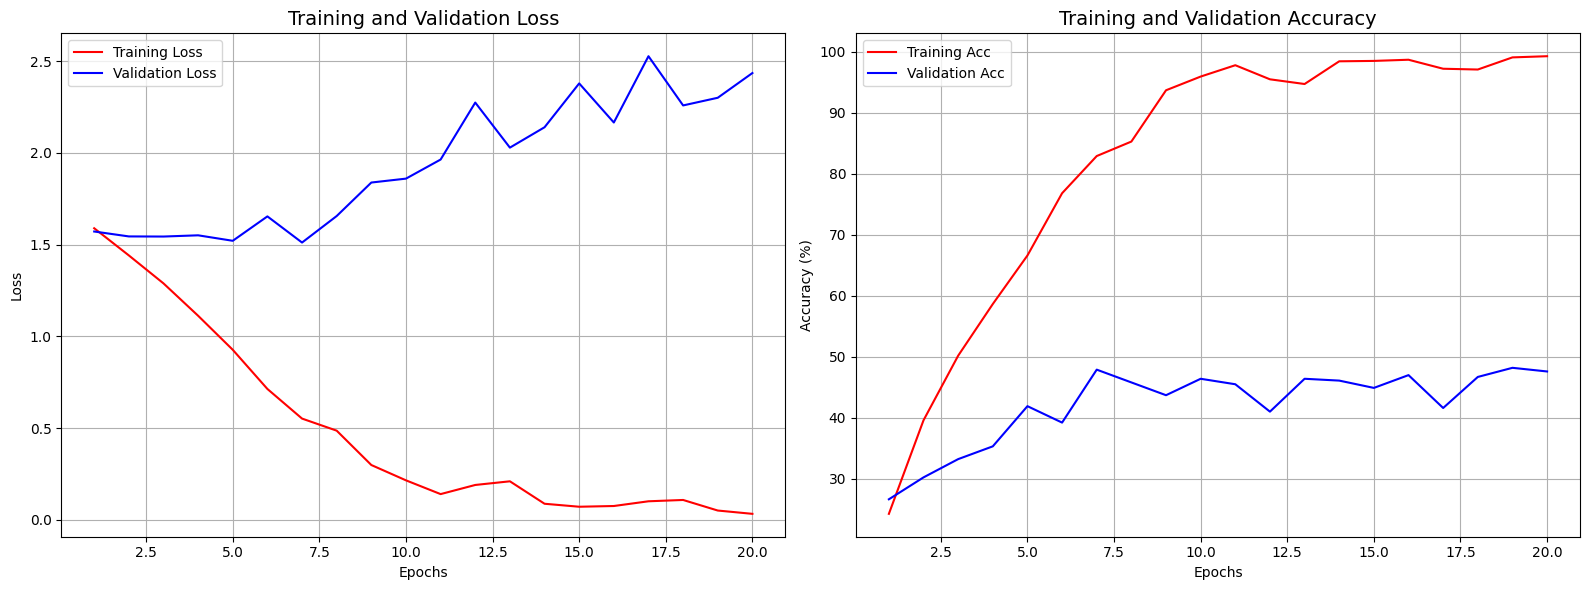

In [60]:
import matplotlib.pyplot as plt

# Define the number of epochs (same as your training loop)
epochs = range(1, 21)

# Set up the plotting grid (1 row, 2 columns)
plt.figure(figsize=(16, 6))

# --- Graph 1: Loss ---
plt.subplot(1, 2, 1) # (rows, columns, current plot index)
# Plot your training loss list vs epochs
plt.plot(epochs, train_loss_total, 'r', label='Training Loss')
# Plot your validation loss list vs epochs
plt.plot(epochs, val_loss_total, 'b', label='Validation Loss')

plt.title('Training and Validation Loss', fontsize=14)
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

# --- Graph 2: Accuracy ---
plt.subplot(1, 2, 2)
# Plot your training accuracy list vs epochs
plt.plot(epochs, train_acc_total, 'r', label='Training Acc')
# Plot your validation accuracy list vs epochs
plt.plot(epochs, val_acc_total, 'b', label='Validation Acc')

plt.title('Training and Validation Accuracy', fontsize=14)
plt.xlabel('Epochs')
plt.ylabel('Accuracy (%)')
plt.legend()
plt.grid(True)

# Show the final graphs
plt.tight_layout()
plt.show()